In [20]:
from pathlib import Path

from aieng.forecasting.data import DataService
from aieng.forecasting.data.adapters import StatCanAdapter


CPI_TABLE_ID = "18-10-0004-11"

# Notebook lives at scripts/; data cache is at repo root / data/statcan.
# Jupyter sets the working directory to the notebook's location, so ../data/statcan is correct.
CACHE_DIR = Path("../data/statcan")


svc = DataService()
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Fetching StatCan table {CPI_TABLE_ID} → cache: {CACHE_DIR.resolve()}")
print()

succeeded = 0
failed = 0

adapter = StatCanAdapter(
    table_id=CPI_TABLE_ID,
    member_filter={
        "GEO": "Canada",
        "Products and product groups": "Fresh vegetables",
        # "Type of currency": "European euro, daily average",
    },
    cache_dir=CACHE_DIR,
)

Fetching StatCan table 18-10-0004-11 → cache: /Users/ethanjackson/agentic-forecasting/data/statcan



In [21]:
ts = adapter.fetch()
ts

,timestamp,value
0,1949-01-01,9.3
1,1949-02-01,10.3
2,1949-03-01,10.2
3,1949-04-01,10.5
4,1949-05-01,10.0
...,...,...
921,2025-10-01,179.9
922,2025-11-01,192.1
923,2025-12-01,197.0
924,2026-01-01,202.2


<Axes: xlabel='timestamp'>

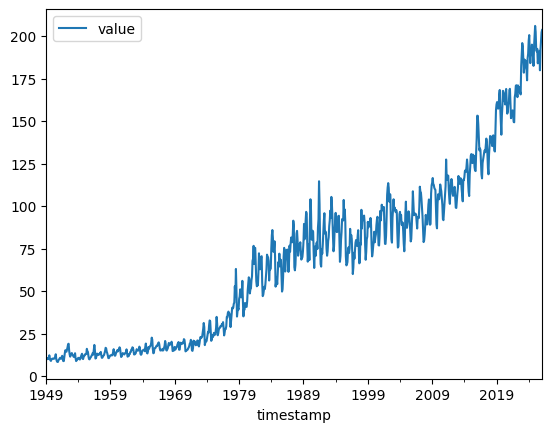

In [23]:
ts.set_index("timestamp").plot()